# 3. Task 2.3: Recommender System

Two approaches:
1. **Content-based**: recommend trails similar to a query trail using cosine similarity on each of our 4 vectorizations
2. **Collaborative filtering**: simulate user-trail interactions from `rating_score` and compare SVD vs KNN with the Surprise library

At the end we compare both approaches.

In [ ]:
# surprise is not happy with numpy
!pip install scikit-surprise "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.3 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554984 sha256=d52466118f61a8ba0346b8c6fd5da51b738258e83256226946443f9918ae5cdb
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following 

In [14]:
# Connect to google drive
from google.colab import drive
colab = True

# 2. Set the directory path first
if colab:
    drive.mount('/content/drive')
    DIRECTORY = "/content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo"
else:
    DIRECTORY = ".."

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# pip install scikit-surprise

import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# load the DataFrame and all vectorizations
df = pd.read_pickle(DIRECTORY + "/data/trails2.pkl")
df = df.reset_index(drop=True)  # make sure index matches matrix rows

tfidf_matrix  = sp.load_npz(DIRECTORY + "/data/tfidf_matrix.npz")
fasttext_matrix = np.load(DIRECTORY + "/data/fasttext_matrix.npy")
lda_matrix    = np.load(DIRECTORY + "/data/lda_matrix.npy")
bert_matrix   = np.load(DIRECTORY + "/data/bert_matrix.npy")

print(f"Trails: {len(df)}")
print("Matrices:", tfidf_matrix.shape, fasttext_matrix.shape, lda_matrix.shape, bert_matrix.shape)

Trails: 5642
Matrices: (5642, 5000) (5642, 100) (5642, 20) (5642, 384)


In [ ]:
df

,tour_id,url,source,share_url,name,name_original,sport,tour_type,difficulty,difficulty_technical,...,categories,tags,rating_score,rating_count,visitors,author_name,author_id,created_at,changed_at,scraped_at
0,e1000043794,https://www.komoot.com/smarttour/e1000043794,komoot,https://www.komoot.com/smarttour/e1000043794/c...,Cabezón Valley Loop,Cabezón de la Sal - La Cocina – circular por e...,mtb,editorial_tour,moderate,dm#t2,...,"[bridge, challenging, climb, intermediate, riv...",[],3.000000,2,4,komoot,komoot,2022-12-28T16:29:34.665Z,2026-02-26T19:29:23.886Z,2026-04-28T14:18:52.970602+00:00
1,e1000263300,https://www.komoot.com/smarttour/e1000263300,komoot,https://www.komoot.com/smarttour/e1000263300/l...,Lac de Clarens Loop from Casteljaloux,Tour du Lac de Clarens – boucle à Casteljaloux,hike,editorial_tour,moderate,t2,...,"[beach, facilities, family_friendly, forest, l...",[],4.000000,1,8,komoot,komoot,2022-12-29T05:11:20.024Z,2026-02-26T19:29:26.579Z,2026-04-27T12:24:10.890329+00:00
2,e1000271422,https://www.komoot.com/smarttour/e1000271422,komoot,https://www.komoot.com/smarttour/e1000271422/p...,Puig de ses Torretes Loop,Puig de ses Torretes y cala Sol d'en Serrà — c...,hike,editorial_tour,moderate,t2,...,"[beach, challenging, family_friendly, intermed...",[],4.406393,219,799,komoot,komoot,2022-12-29T06:30:00.624Z,2026-02-26T19:29:27.576Z,2026-04-27T11:46:53.113100+00:00
3,e1000272479,https://www.komoot.com/smarttour/e1000272479,komoot,https://www.komoot.com/smarttour/e1000272479/b...,"Barbaste, Béas, and Lausseignan Hike",Barbaste et le Moulin d'Henri IV – boucle,hike,editorial_tour,moderate,t2,...,"[bridge, castle, historical_site, intermediate...",[],4.500000,2,19,komoot,komoot,2022-12-29T06:37:18.371Z,2026-02-26T19:32:35.081Z,2026-04-27T12:21:53.751712+00:00
4,e1000289420,https://www.komoot.com/smarttour/e1000289420,komoot,https://www.komoot.com/smarttour/e1000289420/p...,Puig Tomir Loop from Lluc,Puig Tomir por el paso de Pedregueret — circul...,hike,editorial_tour,difficult,t3,...,"[challenging, climb, family_friendly, forest, ...",[],4.309524,126,594,komoot,komoot,2022-12-29T07:37:16.308Z,2026-02-26T19:32:36.312Z,2026-04-27T12:23:32.885992+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,e999792793,https://www.komoot.com/smarttour/e999792793,komoot,https://www.komoot.com/smarttour/e999792793/ca...,Camino Mozárabe and Guadalquivir Loop,Cordel de la Campiña – circular desde Córdoba ...,hike,editorial_tour,difficult,t1,...,"[bridge, family_friendly, historical_site, int...",[],2.000000,2,6,komoot,komoot,2022-12-28T11:25:42.385Z,2026-02-26T19:29:19.670Z,2026-04-27T09:02:23.942718+00:00
5638,e999830014,https://www.komoot.com/smarttour/e999830014,komoot,https://www.komoot.com/smarttour/e999830014/mo...,Mozarabic Trail: Baena to Cueva del Yeso,Baena y Cueva del Yeso,hike,editorial_tour,difficult,t1,...,"[cave, historical_site, intermediate, settleme...",[],NaN,0,0,komoot,komoot,2022-12-28T12:11:05.486Z,2026-02-26T19:29:20.815Z,2026-04-27T09:15:06.144791+00:00
5639,e999958404,https://www.komoot.com/smarttour/e999958404,komoot,https://www.komoot.com/smarttour/e999958404/la...,Laguna de Zóñar Loop,Laguna de Zóñar – circular,hike,editorial_tour,moderate,t1,...,"[facilities, family_friendly, lake, natural_mo...",[],5.000000,1,5,komoot,komoot,2022-12-28T14:51:24.640Z,2026-02-26T19:29:21.951Z,2026-04-27T09:30:37.436059+00:00
5640,e999978793,https://www.komoot.com/smarttour/e999978793,komoot,https://www.komoot.com/smarttour/e999978793/vi...,Villafranca de Córdoba – Iron Bridge,Villafranca de Córdoba – circular al Puente de...,hike,editorial_tour,moderate,t1,...,"[bridge, facilities, family_friendly, historic...",[],3.000000,1,2,komoot,komoot,2022-12-28T15:14:39.539Z,2026-02-26T19:29:22.814Z,2026-04-27T09:00:16.897297+00:00


## Part 1 — Content-based recommender

For a given trail, compute cosine similarity against all others and return the top-N most similar.
We do this for each vectorization so we can compare results.

In [ ]:
# precompute full similarity matrices (can be slow for large datasets)
# for production you'd do this on-the-fly per query, but here we want to compare vectorizations

print("Computing similarity matrices...")
sim_tfidf    = cosine_similarity(tfidf_matrix)
sim_fasttext = cosine_similarity(fasttext_matrix)
sim_lda      = cosine_similarity(lda_matrix)
sim_bert     = cosine_similarity(bert_matrix)
print("Done")

Computing similarity matrices...
Done


In [ ]:
def recommend_content_based(trail_idx: int, sim_matrix: np.ndarray,
                             df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """Return top_n most similar trails to trail_idx"""
    scores = sim_matrix[trail_idx].copy()
    scores[trail_idx] = -1  # exclude the query trail
    top_idx = scores.argsort()[::-1][:top_n]
    result = df.iloc[top_idx][["name", "sport", "difficulty", "distance_m",
                                 "rating_score", "region"]].copy()
    result["similarity"] = scores[top_idx].round(3)
    return result


# example: recommend similar trails to trail #0
query_idx = 0
query_trail = df.iloc[query_idx]
print(f"Query trail: '{query_trail['name']}' | Sport: {query_trail['sport']}")
print()

for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    print(f"--- {name} recommendations ---")
    print(recommend_content_based(query_idx, sim_mat, df, top_n=5).to_string())
    print()

Query trail: 'Cabezón Valley Loop' | Sport: mtb

--- TF-IDF recommendations ---
                                                 name           sport difficulty    distance_m  rating_score                                      region  similarity
367           Gerês-Xurés and Lindoso Reservoir Trail  touringbicycle  difficult  76364.865426           NaN                                       Bande       0.443
3298              Gravel route through the upper Ebro        mtb_easy  difficult  49575.734331           NaN  National Park Hoces del Alto Ebro y Rudrón       0.402
1976  El Destierro - Camino del Cid Loop from Atienza  touringbicycle  difficult  42015.728744           NaN                                     Atienza       0.365
4339                            Vivir con el Río Loop        racebike       easy  21014.070422           NaN                              Hoya De Teruel       0.344
3778                         Gombrèn from Campdevànol        racebike       easy  25494.927749 

In [ ]:
# evaluation: sport overlap in top-10 recommendations

def sport_precision_at_k(sim_matrix: np.ndarray, df: pd.DataFrame, k: int = 10) -> float:
    """For each trail, check what fraction of its top-k recommendations share its sport"""
    precisions = []
    sports = df["sport"].values
    for i in range(len(df)):
        scores = sim_matrix[i].copy()
        scores[i] = -1
        top_idx = scores.argsort()[::-1][:k]
        same_sport = (sports[top_idx] == sports[i]).sum()
        precisions.append(same_sport / k)
    return float(np.mean(precisions))


print("Sport precision:")
for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    p = sport_precision_at_k(sim_mat, df, k=10)
    print(f"  {name}: {p:.3f}")

Sport precision:
  TF-IDF: 0.217
  FastText: 0.216
  LDA: 0.210
  BERT: 0.219


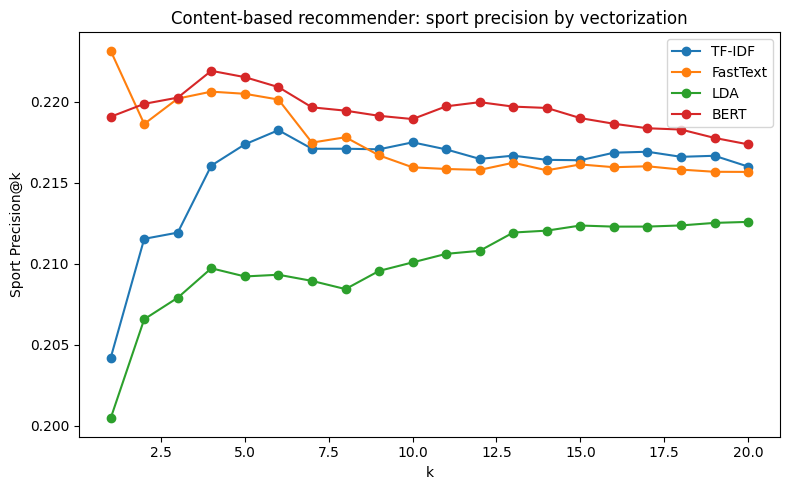

In [16]:
# plot sport precision for k = 1 to 20
k_values = list(range(1, 21))

results = {}
for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    results[name] = [sport_precision_at_k(sim_mat, df, k=k) for k in k_values]

plt.figure(figsize=(8, 5))
for name, vals in results.items():
    plt.plot(k_values, vals, marker="o", label=name)
plt.xlabel("k")
plt.ylabel("Sport Precision@k")
plt.title("Content-based recommender: sport precision by vectorization")
plt.legend()
plt.tight_layout()
plt.savefig(DIRECTORY + "/data/precision_at_k.png", dpi=150)
plt.show()

## Part 2 — Collaborative Filtering

Interaction matrix

In [17]:
df_cf = df.copy()
df_cf["user_id"] = np.random.randint(0, 500, size=len(df))
df_cf["interaction"] = df["rating_score"] * np.log1p(df["visitors"])

In [19]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0, 5))
data = Dataset.load_from_df(df_cf[["user_id", "tour_id", "rating_score"]], reader)

Train models and evaluate with surprise's built-in tools (e.g. cross-validation, RMSE)

In [20]:
from surprise import KNNBasic

# Item-based KNN
sim_options = {
    "name": "cosine",
    "user_based": False
}

knn = KNNBasic(sim_options=sim_options)

In [21]:
from surprise import SVD

# SVD: Matrix factorization-based collaborative filtering
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02)

In [22]:
from surprise.model_selection import cross_validate

cross_validate(svd, data, measures=["RMSE", "MAE"], cv=5, verbose=True)
cross_validate(knn, data, measures=["RMSE", "MAE"], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    nan     nan     nan     nan     nan     nan     nan     
MAE (testset)     nan     nan     nan     nan     nan     nan     nan     
Fit time          0.11    0.05    0.07    0.06    0.05    0.07    0.02    
Test time         0.01    0.00    0.01    0.00    0.00    0.01    0.00    
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    nan     nan     nan     nan     nan    

{'test_rmse': array([nan, nan, nan, nan, nan]),
 'test_mae': array([nan, nan, nan, nan, nan]),
 'fit_time': (1.5250914096832275,
  1.0004682540893555,
  0.7235352993011475,
  0.7197005748748779,
  0.685173749923706),
 'test_time': (0.006639242172241211,
  0.006352424621582031,
  0.00639796257019043,
  0.007636308670043945,
  0.00614476203918457)}

In [23]:
def recommend_cf(user_id, model, df, n=5):
    all_items = df["tour_id"].unique()
    preds = []

    for item in all_items:
        pred = model.predict(user_id, item)
        preds.append((item, pred.est))

    preds.sort(key=lambda x: x[1], reverse=True)
    top_items = [i for i, _ in preds[:n]]

    return df[df["tour_id"].isin(top_items)]